# Step 3: RFM Feature Engineering
Transform raw transactions into per-customer RFM metrics:
- **Recency** — days since last purchase
- **Frequency** — number of orders
- **Monetary** — total spend

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

df = pd.read_csv('../data/processed/online_retail_clean.csv', parse_dates=['InvoiceDate'])
print(df.shape)
df.head()

(4998, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,575867,23242,TREASURE TIN BUFFALO BILL,6,2011-11-11 12:44:00,2.08,15034,United Kingdom,12.48
1,559899,37450,CERAMIC CAKE BOWL + HANGING CAKES,12,2011-07-13 12:24:00,2.95,12528,Germany,35.40
2,569401,23271,CHRISTMAS TABLE SILVER CANDLE SPIKE,16,2011-10-04 08:56:00,0.83,15111,United Kingdom,13.28
3,560041,22625,RED KITCHEN SCALES,2,2011-07-14 14:46:00,8.50,14156,EIRE,17.00
4,548257,85099B,JUMBO BAG RED RETROSPOT,200,2011-03-30 10:54:00,1.65,13802,United Kingdom,330.00


## 3.1 Compute RFM

In [2]:
# Reference date: one day after the last transaction in the dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Reference date:', reference_date)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f'\nRFM table: {rfm.shape[0]} customers')
rfm.head(10)

Reference date: 2011-12-10 12:50:00

RFM table: 2009 customers


,CustomerID,Recency,Frequency,Monetary
0,12347,40,2,78.90
1,12348,319,2,83.52
2,12349,19,1,12.50
3,12350,310,1,65.20
4,12352,36,4,421.65
5,12354,232,1,46.90
6,12357,33,1,30.60
7,12359,305,1,7.80
8,12360,52,1,6.80
9,12362,3,3,74.70


In [3]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,2009.000000,2009.000000,2009.000000,2009.000000
mean,15272.988552,119.890493,1.934296,52.090886
std,1726.185206,107.023376,2.538481,191.129670
min,12347.000000,1.000000,1.000000,0.290000
25%,13774.000000,30.000000,1.000000,11.800000
50%,15296.000000,80.000000,1.000000,19.920000
75%,16775.000000,198.000000,2.000000,42.500000
max,18287.000000,374.000000,51.000000,4461.990000


## 3.2 Visualize RFM Distributions

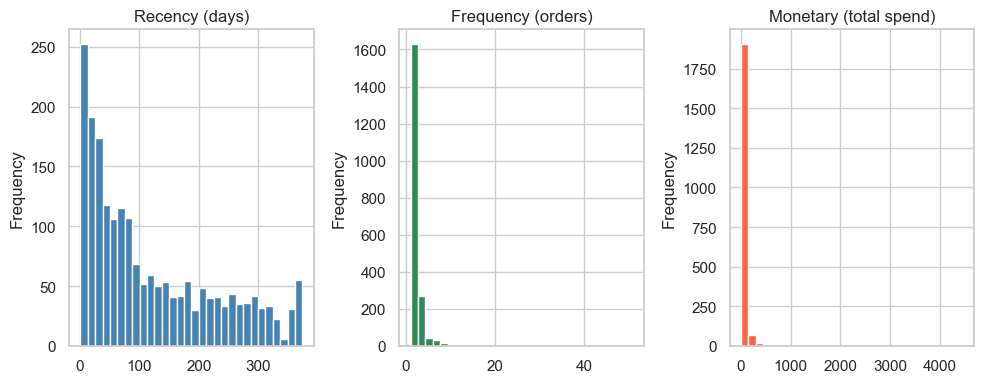

In [4]:
fig, axes = plt.subplots(1, 3)

rfm['Recency'].plot(kind='hist', bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Recency (days)')

rfm['Frequency'].plot(kind='hist', bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Frequency (orders)')

rfm['Monetary'].plot(kind='hist', bins=30, ax=axes[2], color='tomato')
axes[2].set_title('Monetary (total spend)')

plt.tight_layout()
plt.savefig('../data/processed/rfm_distributions.png', dpi=150)
plt.show()

## 3.3 Normalize (Log + StandardScaler)
RFM features are heavily right-skewed. We log-transform first, then standardize so K-Means treats all features equally.

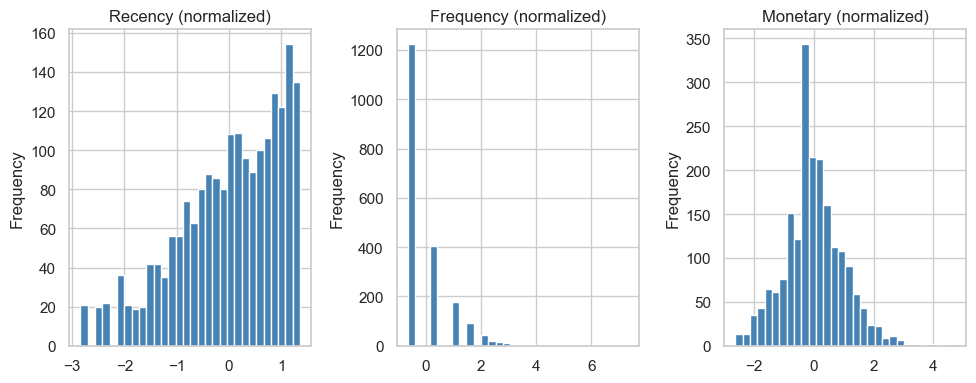

In [5]:
from sklearn.preprocessing import StandardScaler

rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log = np.log1p(rfm_log)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

fig, axes = plt.subplots(1, 3)
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    rfm_scaled_df[col].plot(kind='hist', bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} (normalized)')

plt.tight_layout()
plt.savefig('../data/processed/rfm_normalized.png', dpi=150)
plt.show()

## 3.4 Save

In [6]:
rfm.to_csv('../data/processed/rfm.csv', index=False)
np.save('../data/processed/rfm_scaled.npy', rfm_scaled)
print('Saved rfm.csv and rfm_scaled.npy')

Saved rfm.csv and rfm_scaled.npy
